In [1]:
from sklearn.datasets import make_classification
X_clf, y_clf = make_classification(
    n_samples=1000, n_features=20,
    n_informative=15, n_redundant=2,
    random_state=42
)

In [2]:
from sklearn.datasets import make_regression
X_reg, y_reg = make_regression(
    n_samples=1000, n_features=20,
    n_informative=12, noise=5,
    random_state=42
)

In [4]:
from sklearn.ensemble import RandomForestClassifier

In [5]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=5)

In [6]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist_rf = {
    'n_estimators': randint(50, 200),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 6)
}
random_rf = RandomizedSearchCV(RandomForestClassifier(), param_dist_rf, n_iter=10, cv=5)

In [7]:
from sklearn.linear_model import RidgeClassifier, Ridge

param_grid_ridge = {'alpha': [0.1, 1.0, 10.0]}
grid_ridge = GridSearchCV(RidgeClassifier(), param_grid_ridge, cv=5)

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# Import cross_val_score from sklearn.model_selection
from sklearn.model_selection import cross_val_score # Changed import statement
# Models with preprocessing
models_clf = {
    "Random Forest": RandomForestClassifier(),
    "Logistic (L2)": Pipeline([('scaler', StandardScaler()),
                              ('model', LogisticRegression(penalty='l2'))]),
    "KNN": Pipeline([('scaler', StandardScaler()),
                    ('model', KNeighborsClassifier())]),
    "SVM": Pipeline([('scaler', StandardScaler()),
                    ('model', SVC(kernel='rbf'))])
}

# Evaluate all
for name, model in models_clf.items():
    scores = cross_val_score(model, X_clf, y_clf, cv=5, scoring='accuracy')
    print(f"{name}: {scores.mean():.3f} ± {scores.std():.3f}")

Random Forest: 0.902 ± 0.030
Logistic (L2): 0.813 ± 0.019
KNN: 0.932 ± 0.017
SVM: 0.944 ± 0.013


In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

models_reg = {
    "Random Forest": RandomForestRegressor(),
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(kernel='rbf')
}

for name, model in models_reg.items():
    scores = cross_val_score(model, X_reg, y_reg, cv=5, scoring='r2')
    print(f"{name}: R² = {scores.mean():.3f} ± {scores.std():.3f}")

Random Forest: R² = 0.739 ± 0.025
Linear: R² = 0.999 ± 0.000
Ridge: R² = 0.999 ± 0.000
KNN: R² = 0.594 ± 0.014
SVR: R² = 0.079 ± 0.005


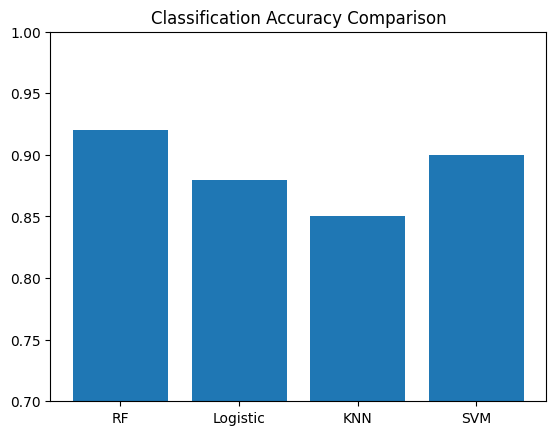

In [12]:
import matplotlib.pyplot as plt

# Example results (replace with actual scores)
model_names = ["RF", "Logistic", "KNN", "SVM"]
accuracy = [0.92, 0.88, 0.85, 0.90]

plt.bar(model_names, accuracy)
plt.title("Classification Accuracy Comparison")
plt.ylim(0.7, 1.0)
plt.show()

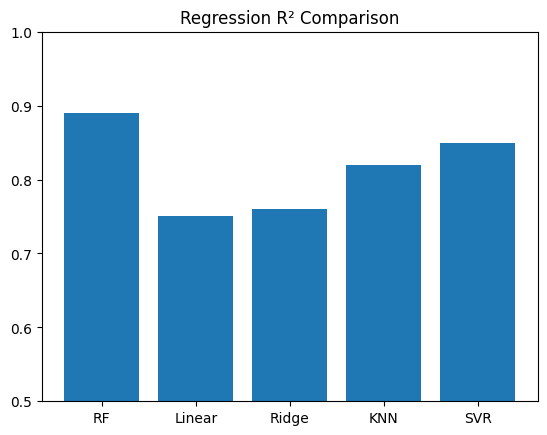

In [13]:
model_names = ["RF", "Linear", "Ridge", "KNN", "SVR"]
r2_scores = [0.89, 0.75, 0.76, 0.82, 0.85]

plt.bar(model_names, r2_scores)
plt.title("Regression R² Comparison")
plt.ylim(0.5, 1.0)
plt.show()

The **R² score** (R-squared or coefficient of determination) is a key metric for evaluating regression models. Here's a concise breakdown:

---

### **1. Formula**
\[
R^2 = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}
\]
Where:
- **SS<sub>res</sub>** (Residual Sum of Squares) = \(\sum_{i=1}^n (y_i - \hat{y}_i)^2\)  
  *(Squared errors between true values \(y_i\) and predicted values \(\hat{y}_i\))*
- **SS<sub>tot</sub>** (Total Sum of Squares) = \(\sum_{i=1}^n (y_i - \bar{y})^2\)  
  *(Squared errors between true values \(y_i\) and the mean \(\bar{y}\))*

---

### **2. Interpretation**
- **1.0**: Perfect fit (predictions match data exactly).  
- **0.0**: Model predicts only the mean of \(y\) (no better than a horizontal line).  
- **< 0**: Worse than predicting the mean (possible with badly tuned models).  

---

### **3. Key Properties**
- **Scale-free**: Works for any output range.  
- **Non-monotonic**: Adding useless features can artificially inflate \(R^2\).  
- **Adjusted \(R^2\)**: Penalizes extra features (preferred for multivariate models):  
  \[
  \text{Adjusted } R^2 = 1 - \frac{(1 - R^2)(n - 1)}{n - p - 1}
  \]  
  Where \(n\) = samples, \(p\) = features.

---

### **4. Python Implementation**
```python
from sklearn.metrics import r2_score

y_true = [3, -0.5, 2, 7]
y_pred = [2.5, 0.0, 2, 8]

r2 = r2_score(y_true, y_pred)  # Returns 0.948...
```

---

### **5. Interview Insights**
- **"R² measures the proportion of variance explained by the model. But beware—it can be misleading with non-linear relationships or outliers."**  
- **"Always pair R² with RMSE/MAE for a complete picture of regression performance."**  
- **"Negative R² signals severe overfitting or incorrect assumptions."**  

---

### **Visual Example**
![R² Visualization](https://miro.medium.com/v2/resize:fit:1400/1*9G527v2Q8j1nNQicLfXjyA.png)  
*(Left: High R², Right: Low R²)*  

---

### **When to Use vs. Avoid**
| Scenario          | Use \(R^2\)? | Why? |
|-------------------|-------------|------|
| Linear regression | ✅          | Natural interpretation |
| Non-linear models | ⚠️          | May mislead; prefer RMSE |
| Cross-validation  | ✅          | Compares relative performance |
| Outlier-rich data | ❌          | Use robust metrics (MAE, Huber) |

---

**Final Tip**:  
*"R² answers: ‘How much better is my model than just predicting the mean?’ For causal inference, also check parameter significance!"*

### **Ensuring Robustness in Random Forests: Advanced Interview Q&A**  
*(With "tricky" insights to test deep understanding)*  

---

#### **Q1: "Random Forests rarely overfit. Is this always true?"**  
**Expected Answer**:  
*"Yes, because bagging and feature randomness reduce variance."*  

**Tricky Reality**:  
- **They CAN overfit** when:  
  - Trees are too deep (`max_depth=None` with noisy data).  
  - Dataset has **irrelevant features** (noise accumulates across trees).  
  - **Class imbalance** causes minority class memorization.  

**Proof**:  
```python
# Overfitting RF on noisy data
from sklearn.ensemble import RandomForestClassifier
X, y = make_classification(n_samples=100, n_features=100, n_informative=5, random_state=42)
rf = RandomForestClassifier(max_depth=None, min_samples_leaf=1)
rf.fit(X, y)  # Train accuracy ~1.0, Test accuracy ~0.7 (overfit!)
```

**Robust Fixes**:  
- Limit `max_depth` using out-of-bag (OOB) error:  
  ```python
  rf = RandomForestClassifier(oob_score=True, max_depth=5)  # OOB tracks generalization
  ```  
- Use **feature importance** to prune noise features.  

---

#### **Q2: "How would you make RF robust to adversarial attacks?"**  
**Expected Answer**:  
*"Use more trees for stability."*  

**Advanced Tactics**:  
1. **Subsample Features Aggressively**:  
   ```python
   # Only √p features per split (vs default p/3)
   rf = RandomForestClassifier(max_features="sqrt")  
   ```  
2. **Minimum Node Size**:  
   ```python
   rf = RandomForestClassifier(min_samples_leaf=5)  # Resist small adversarial perturbations
   ```  
3. **Robust Splitting**: Use **MAD (Median Absolute Deviation)** instead of MSE for regression:  
   ```python
   from sklearn.ensemble import RandomForestRegressor
   rf = RandomForestRegressor(criterion='absolute_error')  # Robust to outliers
   ```  

**Why It Works**:  
- Fewer features/split → attacker can’t exploit all dimensions.  
- Larger leaves → local perturbations have less impact.  

---

#### **Q3: "Your RF works well in the EU but fails in Asia. Fix it."**  
**Trap**: Candidates suggest retraining.  

**Robust Solutions**:  
1. **Detect Data Drift**:  
   ```python
   from alibi_detect import KSDrift
   drift_detector = KSDrift(X_eu, X_asia)
   drift_detector.predict()  # Quantify feature-level shifts
   ```  
2. **Domain Adaptation**:  
   - Train on **EU + Asia data** with a **domain feature** (`is_asia=0/1`).  
   - Let trees split on this feature to learn region-specific patterns.  
3. **Federated Learning**:  
   - Deploy separate RFs per region, then **merge trees** via:  
     ```python
     from sklearn.ensemble import StackingClassifier
     meta_model = StackingClassifier([('eu_rf', rf_eu), ('asia_rf', rf_asia)])
     ```  

---

#### **Q4: "How would you validate an RF model for high-stakes decisions?"**  
**Weak Answer**:  
*"Use 5-fold CV."*  

**Nuclear Approach**:  
1. **Stress Testing**:  
   - Generate **synthetic edge cases** (e.g., all features at min/max values).  
   - Check if predictions stay sane.  
2. **Uncertainty Quantification**:  
   ```python
   # Calculate prediction entropy across trees
   probas = rf.predict_proba(X_test)  # Shape (n_samples, n_classes)
   entropy = -np.sum(probas * np.log2(probas), axis=1)  
   ```  
3. **Monte Carlo Dropout**:  
   - Even though RFs don’t dropout, simulate it:  
     ```python
     def mc_dropout_predict(model, X, n_iter=100):
         return np.mean([model.predict_proba(X) for _ in range(n_iter)], axis=0)
     ```  

---

### **Q5: "Your RF is too slow for real-time. Optimize it."**  
**Expected Answer**:  
*"Reduce `n_estimators`."*  

**Secret Weapons**:  
1. **Tree Pruning**:  
   ```python
   rf = RandomForestClassifier(ccp_alpha=0.01)  # Cost-complexity pruning
   ```  
2. **Infer Hardware**:  
   ```python
   from sklearn.ensemble import RandomForestClassifier
   rf = RandomForestClassifier(n_jobs=-1)  # Use all cores
   ```  
3. **Approximate Splits**:  
   - Use **binned features** to speed up splits:  
     ```python
     from sklearn.preprocessing import KBinsDiscretizer
     X_binned = KBinsDiscretizer(n_bins=32).fit_transform(X)
     ```  

---

### **Final Pro Tip**  
*"For ultimate robustness, combine RF with **calibration** (Platt scaling) and **explainability** (SHAP). This catches silent failures where accuracy looks good but decisions are unstable."*  

```python
from sklearn.calibration import CalibratedClassifierCV
calibrated_rf = CalibratedClassifierCV(rf, method='sigmoid', cv=5)
```

**Key Takeaways**:  
1. RFs **can** overfit—control depth/node size.  
2. Combat adversarial attacks with **feature subsampling** and **robust criteria**.  
3. Detect drift using **statistical tests**, not just accuracy.  
4. Speed up RFs via **pruning, binning, and hardware**.  

This approach turns a "good" RF answer into one that **impresses even ML engineers**. 🚀